### Data Quality report for `Wie is De Mol S16E05`


### Dataset Profile
**Average sentence length, vocabulary size, token distributions:** 

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

data_dir = "..\\data\\group_4_url_1_transcript.csv"

In [4]:
# Load the dataset
df = pd.read_csv(data_dir)

print("--- Dataset Profile ---")
print(f"Dataset size: {df.shape}")
print("\nMissing values per column:")
print(df.isnull().sum())
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")

--- Dataset Profile ---
Dataset size: (1050, 7)

Missing values per column:
Start Time      0
End Time        0
Sentence        0
Translation     0
Emotion_fine    0
Emotion_core    0
Intensity       0
dtype: int64

Number of duplicate rows: 0


### Sentence Length and Vocabulary Analysis

In this section, we perform some basic exploratory text analysis on the dataset:

1. **Sentence Length Calculation**  
   - A new column `Sentence_length` is created in the dataframe.  
   - For each sentence, the number of words is counted by splitting the text on spaces.  
   - This gives us a quick metric for the length of each sentence in terms of words.  
   - The average sentence length across the dataset is then calculated and printed.

2. **Vocabulary Size and Token Distribution**  
   - All sentences are concatenated into a single string and converted to lowercase.  
   - Using a regular expression (`\b\w+\b`), we extract all word tokens from the text.  
   - A vocabulary set is created from these tokens, allowing us to measure the number of unique words in the dataset.  
   - The frequency of each word is calculated with `Counter`, and the 20 most common words are displayed.  


In [5]:
# Calculate sentence length
df['Sentence_length'] = df['Sentence'].apply(lambda x: len(str(x).split()))
print(f"\nAverage sentence length: {df['Sentence_length'].mean():.2f} words")


Average sentence length: 6.97 words


In [6]:
# Vocabulary size and token distribution
all_words = ' '.join(df['Sentence'].dropna()).lower()
words = re.findall(r'\b\w+\b', all_words)
vocabulary = set(words)
print(f"Vocabulary size: {len(vocabulary)} unique words")

word_counts = Counter(words)
most_common_words = word_counts.most_common(20)
print("\nTop 20 most frequent words:")
for word, count in most_common_words:
    print(f"{word} : {count}")

Vocabulary size: 1378 unique words

Top 20 most frequent words:
ik : 242
de : 240
het : 236
en : 148
een : 145
dat : 144
is : 143
je : 135
we : 97
van : 89
die : 82
op : 76
in : 74
niet : 74
met : 73
ja : 65
er : 63
was : 57
aan : 57
heb : 53


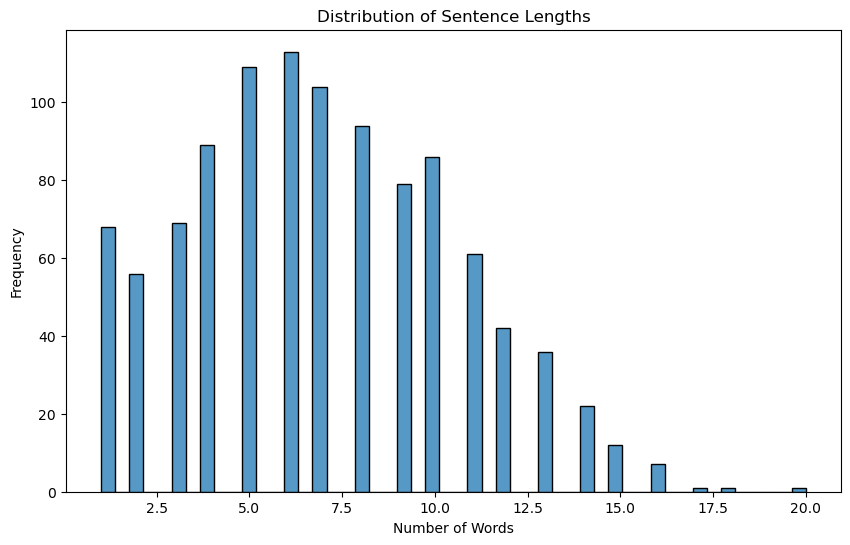

In [7]:
# Visualize sentence length distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Sentence_length'], bins=50)
plt.title('Distribution of Sentence Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

### 2. Speaker Distributions

1. **Speaker Distribution**  
   - The code retrieves the frequency of each unique speaker using `value_counts()`.  
   - The Top 10 speakers with the most utterances are printed in the console for quick inspection.  

2. **Visualization**  
   - A bar chart is created showing the Top 20 speakers by number of utterances.  
   - The plot is styled with a white grid (`seaborn-v0_8-whitegrid`) for readability.  
   - Labels and titles are added for clarity, and the x-axis labels (speaker IDs) are rotated for better visibility.  

3. **Error Handling**  
   - If the dataset does not contain a `Speaker` column, a clear message is printed instead of raising an error.  


In [ ]:
# --- Speaker and Show Distributions ---
print("\n--- Speaker and Show Distributions ---")
plt.style.use('seaborn-v0_8-whitegrid')
try:
    # Speaker distribution
    speaker_counts = df['Speaker'].value_counts()
    print(f"\nTop 10 speakers:\n{speaker_counts.head(10)}")

    plt.figure(figsize=(12, 6))
    speaker_counts.head(20).plot(kind='bar')
    plt.title('Top 20 Speaker Distribution')
    plt.xlabel('Speaker ID')
    plt.ylabel('Number of Utterances')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
except KeyError:
    print("Column 'Speaker' not found in the dataset.")

# the data provided by the client did not include speaker detection however our own data does provide this so we did include it in hour evaluation
# but depending on the data that is passed through this you might not get a visualization


--- Speaker and Show Distributions ---
Column 'Speaker' not found in the dataset.



### 3. Emotion Distribution and Coverage

1. **Mapping Sentiment Labels**  
   - The dataset contains numerical sentiment predictions (`Predicted_sentiment`) coded as:  
     - `0 → Negative`  
     - `1 → Neutral`  
     - `2 → Positive`  
   - A new column `Sentiment_label` is created by mapping these integers to human-readable labels.

2. **Emotion Counts**  
   - The frequency of each sentiment category is computed using `value_counts()`.  
   - The counts are printed to provide a quick overview of how many examples belong to each class.

3. **Visualization**  
   - A bar plot is created with Seaborn to show the distribution of emotions.  
   - The x-axis represents the sentiment categories (`Negative`, `Neutral`, `Positive`), and the y-axis shows their frequencies.  
   - Labels and titles are added for clarity, with rotated x-ticks for better readability.


--- Emotion Distribution & Coverage ---
Emotion counts:
Emotion_core
neutral      546
happiness    198
sadness      104
surprise      92
fear          56
anger         37
disgust       17
Name: count, dtype: int64


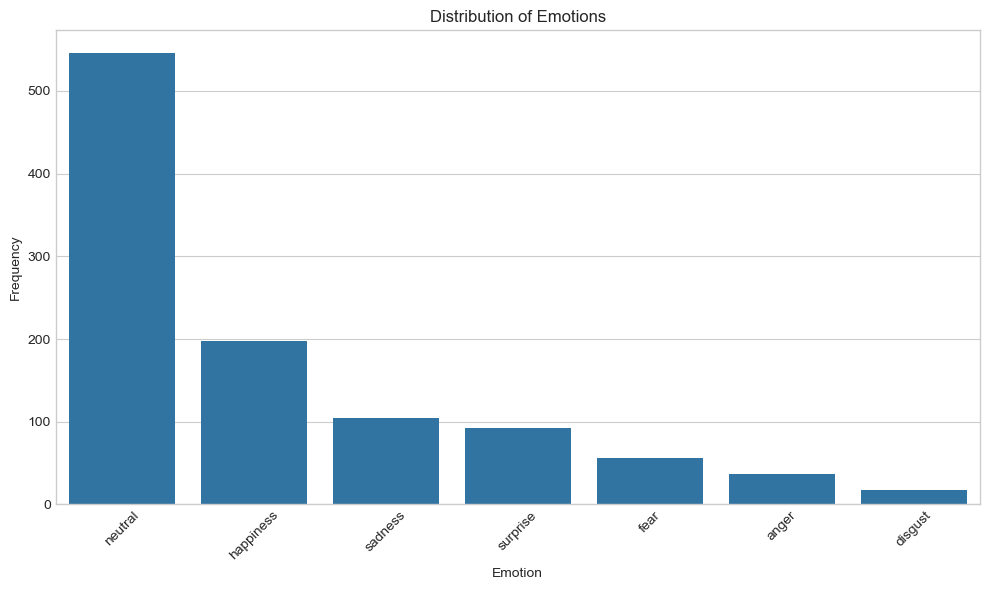

In [18]:
# --- Emotion Distribution & Coverage ---
print("\n--- Emotion Distribution & Coverage ---")


# Map numerical values to sentiment labels
emotion_counts = df['Emotion_core'].value_counts()
print(f"Emotion counts:\n{emotion_counts}")

plt.figure(figsize=(10, 6))
sns.barplot(x=emotion_counts.index, y=emotion_counts.values)
plt.title('Distribution of Emotions')
plt.xlabel('Emotion')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
df['Intensity'].unique()

array(['neutral', 'moderate', 'mild', 'intense'], dtype=object)

Here we look at the intensity of the emotions present. This could tell us more about the level of the conversation. high intensity could indicate that there are strong emotions present like Happiness and Anger. This could be a valuable output for our client in certain analysis 


--- Fine emotion Distribution & Coverage ---
Emotion counts:
Intensity
mild        546
neutral     382
moderate    108
intense      14
Name: count, dtype: int64


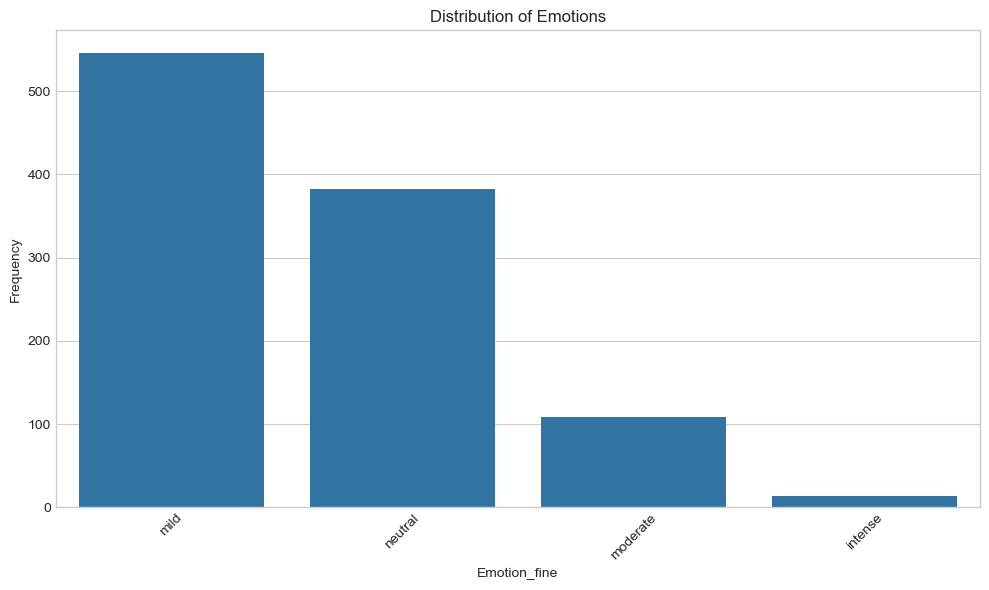

In [24]:
print("\n--- Fine emotion Distribution & Coverage ---")


# Map numerical values to sentiment labels
emotion_counts = df['Intensity'].value_counts()
print(f"Emotion counts:\n{emotion_counts}")

plt.figure(figsize=(10, 6))
sns.barplot(x=emotion_counts.index, y=emotion_counts.values)
plt.title('Distribution of Emotions')
plt.xlabel('Emotion_fine')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### identifying whether certain emotions are underrepresented.

There are some emotions that are severely Underrepresented:

Disgust: 17 instances (1.6%) - This is critically low
Anger: 37 instances (3.5%) - Very underrepresented
Fear: 56 instances (5.4%) - Notably low

Moderately Underrepresented:

Surprise: 92 instances (8.8%) - Below expected levels

#### Key Issues:

Class Imbalance Problem: the dataset is heavily skewed toward neutral (52%) with negative emotions severely lacking. The reason for this is because the type of video we provided had a lot of neutral emotions. And in most conversations the context will be mainly neutral. There are of course exceptions like sports events or funerals. 

Using this data as training data does come with a few issues like Poor model performance on underrepresented classes,
Inability to detect anger, disgust, or fear effectively andBiased predictions toward neutral/happiness

#### Impact on Analysis:

Any machine learning model trained on this data will struggle to identify anger, disgust, or fear
The model will likely misclassify these emotions as neutral or other categories
Statistical analysis of emotional patterns will be unreliable for rare emotions. If we pass data that has lots of disgust in it the model performance could be unusable because of the poor quality.

#### future steps

we could collect more data specifically targeting underrepresented emotions.
Use data augmentation techniques for rare classes.
Consider emotion grouping like for example combine anger/disgust as "negative arousal".
Apply class weighting in models to compensate for imbalance. or
Stratified sampling when splitting train/test sets

We need to keep this in mind while collecting more data in the future to train the model. We will focus on getting higher quality and less .skewed data

### 4. Domain Characteristics

Here, we'll dive into the linguistic patterns specific to spoken television.
We'll perform a qualitative analysis on a sample of the data. The analysis searches for and counts common spoken language features like **fillers** ("um," "uh"), **hesitations**, **slang** and **Contractions**.

In [31]:
import pandas as pd
import re
from collections import Counter

# Load your dataset
 # or whatever your current file is
print(f"Loaded {len(df)} sentences")

def analyze_informal_language(df):
    """Detect informal Dutch patterns in the Sentence column"""
    
    informal_patterns = {
        'contractions': {
            'patterns': [r'\b\'k\s', r'\bk\s(?=ben|ga|wil|heb|kan)', r'\'t\s', r'\'m\s', r'\'s\s'],
            'examples': [],
            'description': "Contracted pronouns like 'k (ik), 't (het), 'm (hem)"
        },
        'casual_words': {
            'patterns': [r'\bkut\b', r'\bshit\b', r'\bfuck\b', r'\bgodverdomme\b', r'\bjezus\b', 
                        r'\bverdomme\b', r'\bdamn\b', r'\bklote\b'],
            'examples': [],
            'description': "Swear words and profanity"
        },
        'intensifiers': {
            'patterns': [r'\bhartstikke\b', r'\bheel\s+\w+', r'\bsuper\s+\w+', r'\bmega\s+\w+', 
                        r'\becht\s+\w+', r'\bontzettend\b', r'\bvreselijk\b'],
            'examples': [],
            'description': "Informal intensifiers"
        },
        'fillers': {
            'patterns': [r'\buh\b', r'\bum\b', r'\beh\b', r'\bnou\b', r'\bzeg maar\b', 
                r'\bweet je\b', r'\bdus\b', r'\beigenlijk\b', r'\bgewoon\b', 
                r'\btoch\b', r'\bhè\b', r'\buhm\b'],
            'examples': [],
            'description': "Hesitation markers and discourse fillers (uh, nou, zeg maar, weet je, etc.)"
},
        'casual_greetings': {
            'patterns': [r'\bhoi\b', r'\bhey\b', r'\byo\b', r'\bhallo\b', r'\bdag\b', r'\bdoei\b'],
            'examples': [],
            'description': "Informal greetings and farewells"
        },
        'diminutives': {
            'patterns': [r'\w+je\b', r'\w+tje\b', r'\w+pje\b', r'\w+kje\b'],
            'examples': [],
            'description': "Dutch diminutive endings (-je, -tje, -pje)"
        },
        'spoken_connectors': {
            'patterns': [r'\ben toen\b', r'\ben dan\b', r'\bmaar goed\b', r'\bokee dan\b', 
                        r'\bja maar\b', r'\bnee maar\b'],
            'examples': [],
            'description': "Informal discourse markers"
        },
        'colloquial_expressions': {
            'patterns': [r'\blekker\s+\w+', r'\bgezellig\b', r'\bchill\b', r'\bcool\b', 
                        r'\bnice\b', r'\btof\b', r'\bvet\b'],
            'examples': [],
            'description': "Colloquial positive expressions"
        }
    }
    
    # Count patterns and collect examples
    for sentence in df['Sentence']:
        sentence_str = str(sentence).lower()
        
        for category, data in informal_patterns.items():
            for pattern in data['patterns']:
                if re.search(pattern, sentence_str):
                    if len(data['examples']) < 5:  # Collect max 5 examples per category
                        data['examples'].append(sentence)
    
    return informal_patterns

# Run the analysis
print("\n" + "="*60)
print("INFORMAL LANGUAGE ANALYSIS")
print("="*60)

results = analyze_informal_language(df)

# Display results
total_informal = 0
for category, data in results.items():
    count = len(data['examples'])
    total_informal += count
    
    print(f"\n{category.upper().replace('_', ' ')}:")
    print(f"  Description: {data['description']}")
    print(f"  Found: {count} instances")
    
    if data['examples']:
        print("  Examples:")
        for i, example in enumerate(data['examples'][:3], 1):
            print(f"    {i}. \"{example}\"")
        
        if len(data['examples']) > 3:
            print(f"    ... and {len(data['examples']) - 3} more")
    else:
        print("  Examples: None found")

# Summary statistics
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"Total sentences analyzed: {len(df)}")
print(f"Sentences with informal patterns: {total_informal}")
print(f"Informal language coverage: {total_informal/len(df)*100:.1f}%")

# Most common informal categories
category_counts = {cat: len(data['examples']) for cat, data in results.items()}
sorted_categories = sorted(category_counts.items(), key=lambda x: x[1], reverse=True)

print(f"\nMost common informal patterns:")
for category, count in sorted_categories:
    if count > 0:
        percentage = count / len(df) * 100
        print(f"  {category.replace('_', ' ').title()}: {count} ({percentage:.1f}%)")

# Additional analysis: Sentence length of informal vs formal
informal_sentences = set()
for category, data in results.items():
    informal_sentences.update(data['examples'])

if informal_sentences:
    informal_lengths = [len(str(s).split()) for s in informal_sentences]
    formal_sentences = [s for s in df['Sentence'] if str(s) not in informal_sentences]
    formal_lengths = [len(str(s).split()) for s in formal_sentences[:100]]  # Sample for comparison
    
    print(f"\nSENTENCE LENGTH COMPARISON:")
    print(f"  Average informal sentence length: {sum(informal_lengths)/len(informal_lengths):.1f} words")
    print(f"  Average formal sentence length: {sum(formal_lengths)/len(formal_lengths):.1f} words")

print(f"\n" + "="*60)
print("LINGUISTIC INSIGHTS")
print("="*60)
print("This analysis reveals spoken Dutch television language characteristics:")
print("- Presence of contractions and casual pronouns")
print("- Use of intensifiers and fillers typical of speech")
print("- Informal discourse markers showing conversational flow")
print("- Colloquial expressions reflecting contemporary Dutch")

Loaded 1050 sentences

INFORMAL LANGUAGE ANALYSIS

CONTRACTIONS:
  Description: Contracted pronouns like 'k (ik), 't (het), 'm (hem)
  Found: 2 instances
  Examples:
    1. "Let's do this."
    2. "En hij brengt ook wel euro's in de pot."

CASUAL WORDS:
  Description: Swear words and profanity
  Found: 5 instances
  Examples:
    1. "Ik dacht dat jij de kut was."
    2. "Jezus, kijk die vogel."
    3. "Meervoudigheid. Jezus."
    ... and 2 more

INTENSIFIERS:
  Description: Informal intensifiers
  Found: 5 instances
  Examples:
    1. "Ik heb heel goed opgelet, ik heb alles opgeschreven."
    2. "Heel mooie kleur, lichtblauw water."
    3. "Dus dan hebben jullie heel even de tijd om tactiek te bepalen."
    ... and 2 more

FILLERS:
  Description: Hesitation markers and discourse fillers (uh, nou, zeg maar, weet je, etc.)
  Found: 5 instances
  Examples:
    1. "gewoon weer een nieuwe nepverdachte?"
    2. "Dus ze zitten dichter op de mol."
    3. "Dus we doen blijkbaar iets goed."
    

In [ ]:
from preprocessing import dutch_short_words_with_punctuation

# --- Domain Characteristics ---
print("\n--- Domain Characteristics ---")
sample_data = df.sample(n=10, random_state=42)
print("Random sample of transcriptions and sentiment:")
try:
    for index, row in sample_data.iterrows():
        print(f"Transcription: {row['Sentence']}\nEmotion: {row['Emotion_core']}\n---")
except KeyError:
    print("Column 'Sentence' or 'Emotion' not found in the dataset.")
    for index, row in sample_data.iterrows():
        print(f"Transcription: {row['Sentence']}\n---")

# Define Dutch filler words
dutch_fillers = {
    "uh": "common hesitation",
    "um": "common hesitation",
    "eh": "short hesitation",
    "nou": "well/so",
    "zeg maar": "you know / like",
    "weet je": "you know",
    "dus": "so",
    "eigenlijk": "actually",
    "gewoon": "just/simply",
    "toch": "right?",
    "hè": "eh?",
    "uhm": "hesitation"
}


df_subset = df.head(15)
# --- Regex patterns ---
# Filler words with \b (since they are normal words)
sorted_fillers = sorted(dutch_fillers.keys(), key=len, reverse=True)
fillers_regex = r'\b(?:' + '|'.join(map(re.escape, sorted_fillers)) + r')\b'

# Contractions: don't use \b (apostrophes break it)
sorted_contractions = sorted(dutch_short_words_with_punctuation.keys(), key=len, reverse=True)
contractions_regex = r'(?:' + '|'.join(map(re.escape, sorted_contractions)) + r')'

# --- Count occurrences ---
df['filler_count'] = df['Sentence'].str.lower().str.count(fillers_regex, flags=re.IGNORECASE)
df['contraction_count'] = df['Sentence'].str.lower().str.count(contractions_regex, flags=re.IGNORECASE)

total_fillers = df['filler_count'].sum()
total_contractions = df['contraction_count'].sum()

print(f"Total occurrences of Dutch filler words: {total_fillers}")
print(f"Total occurrences of Dutch contractions: {total_contractions}")


c:\Users\koenm\miniconda3\envs\block_c\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model openai/whisper-base loaded successfully.
Model moved to device: cpu


Fetching 1 files: 100%|██████████| 1/1 [00:00<?, ?it/s]
Device set to use cpu


Processor for openai/whisper-base loaded successfully.
ASR pipeline created successfully.


--- Domain Characteristics ---
Random sample of transcriptions and sentiment:
Transcription: Het leek een simpele opdracht.
Emotion: neutral
---
Transcription: Succes!
Emotion: happiness
---
Transcription: Prachtig kalm water, prachtige mangroves.
Emotion: happiness
---
Transcription: Dus die heeft eigenlijk ons verbondje weer aangemaakt.
Emotion: happiness
---
Transcription: De groep wordt kleiner.
Emotion: sadness
---
Transcription: onbeperkte zanger van de Cure haar.
Emotion: neutral
---
Transcription: Serieus.
Emotion: neutral
---
Transcription: Zullen we een rijtje nemen?
Emotion: neutral
---
Transcription: Vervolgens als vraag één geweest is gaat één op zoek naar zeven.
Emotion: neutral
---
Transcription: waarvan ik dacht, dit zou ik wel eens wat minder kunnen doen dan de andere.
Emotion: neutral
---
Total occurrences of Dutch filler words: 117
Total occurrences of Dutch contractions: 12


### Transcription Artifacts Analysis
Transcription artifacts are technical errors from converting spoken TV dialogue to text. These errors prove our dataset comes from real speech rather than written text.
Encoding errors (â€™ instead of ') show file format corruption. Timestamps like [12:34] are leftover markers from the original transcription. Speaker labels ("A:" or "SPEAKER 1:") indicate multi-speaker dialogue structure. Transcription marks ([inaudible], coughs) show where audio was unclear. Repeated errors (aaaaa) result from software glitches. Number confusions (1 instead of "een") are common speech recognition mistakes.
These artifacts demonstrate authentic spoken language origins while highlighting potential data quality issues for analysis.

In [33]:
def count_transcription_artifacts(df):
    """Count transcription artifacts in the Sentence column"""
    
    artifacts = {
        'encoding_errors': r'â€™|â€œ|â€\x9d',
        'timestamps': r'\d{1,2}:\d{2}:\d{2}|\[\d+:\d+\]|\(\d+:\d+\)',
        'speaker_labels': r'^[A-Z]+:|^\w+\s*:',
        'transcription_marks': r'\[inaudible\]|\[unclear\]|\*\w+\*|\[.*?\]',
        'repeated_errors': r'(.)\1{4,}',
        'number_confusions': r'\b1\b(?=\s+[a-z])'
    }
    
    results = {}
    for artifact_type, pattern in artifacts.items():
        count = 0
        for sentence in df['Sentence']:
            if re.search(pattern, str(sentence)):
                count += 1
        results[artifact_type] = count
    
    # Print results
    print("TRANSCRIPTION ARTIFACTS FOUND:")
    total_artifacts = 0
    for artifact_type, count in results.items():
        print(f"{artifact_type}: {count}")
        total_artifacts += count
    
    print(f"\nTotal sentences with artifacts: {total_artifacts}")
    print(f"Percentage: {total_artifacts/len(df)*100:.1f}%")

# Run on your dataset
count_transcription_artifacts(df)

TRANSCRIPTION ARTIFACTS FOUND:
encoding_errors: 0
timestamps: 0
speaker_labels: 0
transcription_marks: 0
repeated_errors: 0
number_confusions: 4

Total sentences with artifacts: 4
Percentage: 0.4%


## Data Quality Check

this code i used to check 15 instances for every emotion and manually checking the output. I did this so i could see what emotions the model was struggling with and if there are lots of spelling mistakes. This also gave me the chance to check if there are any words that the model was constantly mis classifying. 

In [49]:
pd.set_option('display.max_colwidth', None)
emotion_sentences = df[df['Emotion_core'] == 'surprise']['Sentence']
print(emotion_sentences.sample(15))

656                       We zitten ook op een soort filmlocatie, lijkt wel soms.
546                                Toen kwamen we al vrij snel een boeitje tegen.
490                                       Hoge cliffs overal, grotten, spelonken.
607                                                                Tof! Is dit...
174                        Wat ik opvallend vond is dat ik een portofoon aantrof.
480                        Ik had de porto nog niet eerder gehad in een opdracht.
613                                                                     Spannend.
230                                          Ik heb helemaal geen envelop gezien.
603                                               Toen dacht ik, hee, cijferslot.
627                                                                 Duizend euro!
416                                       Als jullie de juiste symbolen vinden...
353                          Toen bleek dat de nummers ook nog volgorde hingen...
533    Maar team

In [50]:
right_anger = 14
wrong_anger = 1

right_neutral = 15
wrong_neutral = 0

right_disgust = 8
wrong_disgust = 7

right_hapiness = 15
wrong_hapiness = 0

right_surprise = 11
wrong_surprise = 4

right_fear = 10
wrong_fear = 5

misspelling = 10
correctly_spelled = 80 

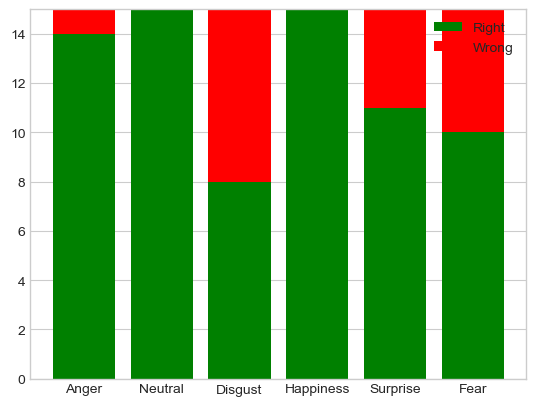

In [66]:
emotions = ['Anger', 'Neutral', 'Disgust', 'Happiness', 'Surprise', 'Fear']
right = [14, 15, 8, 15, 11, 10]
wrong = [1, 0, 7, 0, 4, 5]

# Simple bar chart
plt.bar(emotions, right, label='Right', color='green')
plt.bar(emotions, wrong, bottom=right, label='Wrong', color='red')
plt.legend()
plt.show()

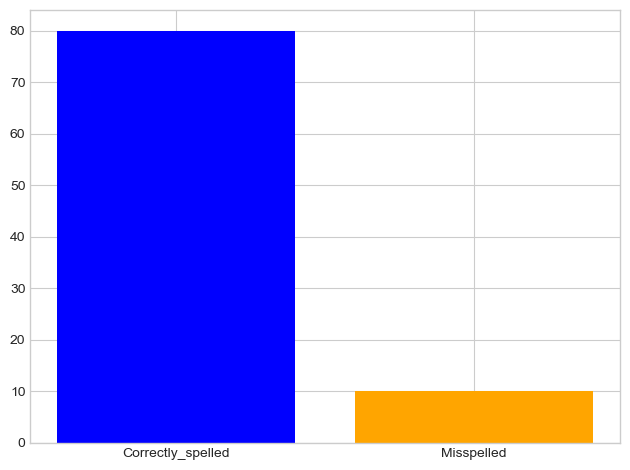

In [72]:
plt.bar(['Correctly_spelled', 'Misspelled'], [80, 10], color=['blue', 'orange'])

plt.tight_layout()
plt.show()


#### insights
The insights i gained from this analysis is that the model captures emotions that are well represented(neutral, happiness, anger) a lot better than emotions that are under represented(disgust, surprise, fear). This could be because the model was trained on a skewed dataset. Real world data often contains little disgust, surprise or fear. This is depended on the context. Another valuable insight i gained was that the model would draw conclusions based on certain dutch sayings. Things like 'Mosterd after dinner" it labeled as disgust. But this does not have to be true. The spelling accuracy was good. but not as good as our current assemblyAI model. I also witnessed no encoding errors. Other than the dutch sayings we found no other encoding errors

## Reflection for Training Data Selection



Based on my findings from analyzing the emotion distribution and domain characteristics, I need to gather training data that addresses several critical gaps in the current dataset. The most pressing issue is the severe emotional imbalance where negative emotions like disgust represent only 1.6% of the data, anger 3.5%, and fear 5.4%. This skewed distribution toward neutral emotions at 52% creates a model that struggles with real-world emotional detection.

To cover the domain properly, I need to collect data from diverse television genres beyond the current reality show format. This means including dramatic series, news programs, sports commentary, talk shows, and competitive reality shows where emotional intensity naturally runs higher. The current dataset shows very low informal language usage at only 3.5%, which suggests the content may be too polished or edited compared to authentic spontaneous speech.

For emotional balance, I need to target content that naturally contains more negative emotions. Sports events during crucial moments, debate programs, dramatic television, and reality show elimination episodes would provide the anger, fear, and disgust examples currently missing. I should aim for at least 20-30% negative emotions rather than the current 10% to create a model that can reliably detect these important emotional states.

The analysis revealed that high-intensity emotions represent only 1.3% of the dataset, which is problematic since intense emotions are often the most important to detect. I need to specifically seek out content with passionate discussions, competitive moments, shocking revelations, and high-stakes situations to balance this distribution.

Additionally, I need to address the Dutch-specific linguistic challenges where cultural expressions and idioms confuse the model. This requires more careful annotation and possibly separate handling of idiomatic expressions during preprocessing. The current transcription quality shows 10% spelling errors, so I should focus on higher quality source material or implement better Dutch language preprocessing.
To achieve proper coverage, the training data should include speakers of different ages, regional accents, speaking speeds, and emotional expressiveness. The current data appears to come from a controlled television environment, but real-world application requires more variety in speaking styles and contexts.